# H2 -- active-region (gap-length) distribution analysis

Analyzes `gap_length_gap_length_production_20260914T045549Z` (see
RESEARCH_LOG.md, 2026-09-14, "H2 production run") against the H2a
(shape collapse) / H2b (tail anomaly) candidate outcomes in
HYPOTHESES.md. Zero-length gaps were already discarded from this data
at collection time. No model is fit as ground truth here -- both
exponential and power-law tail forms are reported side by side for the
researcher to judge, per CLAUDE.md (do not interpret results).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as spstats

DATA_DIR = Path('../../data/raw/gap_length_gap_length_production_20260914T045549Z')
L_VALUES = [100, 200, 400, 800, 1600, 3200, 6400, 12800]

gaps = {L: np.load(DATA_DIR / f'L{L}_gaps.npy') for L in L_VALUES}

with open(DATA_DIR / 'summary.json') as f:
    summary = {row['L']: row for row in json.load(f)}

print(f"{'L':>7} {'n_pooled':>9} {'mean (recomputed)':>18} {'mean (summary.json)':>20} {'std':>8}")
for L in L_VALUES:
    arr = gaps[L]
    print(f"{L:7d} {len(arr):9d} {arr.mean():18.4f} {summary[L]['gap_length_mean']:20.4f} {arr.std(ddof=1):8.4f}")

      L  n_pooled  mean (recomputed)  mean (summary.json)      std
    100      5643            16.1150              16.1150  12.1197
    200      5825            15.7301              15.7301  12.1031
    400      5261            15.5288              15.5288  11.8854
    800      5225            15.6333              15.6333  11.7772
   1600      6544            15.5536              15.5536  11.7249
   3200      7793            15.6646              15.6646  11.8829
   6400     10416            15.6360              15.6360  11.9345
  12800     10530            15.4073              15.4073  11.7394


## Observation: some small gap lengths never occur

Before looking at collapse/tails, the low end of the distribution is
worth showing directly -- gap lengths of 1, 2, and 3 do not appear in
this data at any L (expected, since something must separate two
distinct frozen sites for a nonzero gap to be recorded at all -- a gap
of exactly 1-3 active sites may simply not arise under this dynamics/
definition). Length 5 is also entirely absent at every L tested, while
4 is present with a comparatively large count, and every length from 6
upward is present. This exact pattern (zero count at 1, 2, 3, 5; present
at 4 and at every value from 6 up) recurs identically at all 8 L values
checked, including L=100 and L=12,800 with thousands of samples each --
reported here as an observation, not explained.

In [2]:
print(f"{'l':>3}", *[f'L={L}' for L in L_VALUES], sep='  ')
for l in range(0, 12):
    counts = [int(np.sum(gaps[L] == l)) for L in L_VALUES]
    print(f'{l:3d}', *[f'{c:6d}' for c in counts], sep='  ')

  l  L=100  L=200  L=400  L=800  L=1600  L=3200  L=6400  L=12800
  0       0       0       0       0       0       0       0       0
  1       0       0       0       0       0       0       0       0
  2       0       0       0       0       0       0       0       0
  3       0       0       0       0       0       0       0       0
  4     664     728     650     639     791     882    1302    1365
  5       0       0       0       0       0       0       0       0
  6     508     543     500     498     603     779     943    1013
  7     255     260     246     252     309     377     518     479
  8     307     349     309     295     373     460     589     598
  9     320     342     307     310     365     447     573     616
 10     293     307     264     254     334     389     556     500
 11     274     248     240     250     318     355     464     440


## Raw empirical PMF, P_L(l) vs l, all L overlaid

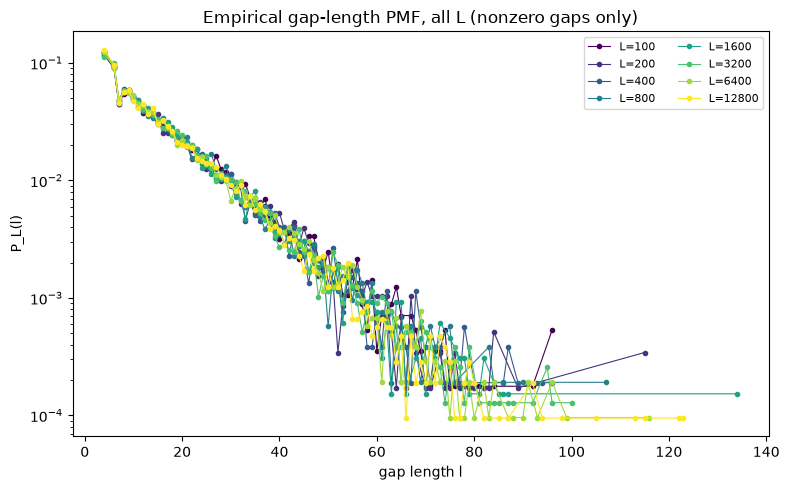

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(L_VALUES)))
for L, color in zip(L_VALUES, cmap):
    arr = gaps[L]
    vals, counts = np.unique(arr, return_counts=True)
    p = counts / len(arr)
    ax.plot(vals, p, marker='o', markersize=3, linewidth=0.8, color=color, label=f'L={L}')
ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlabel('gap length l')
ax.set_ylabel('P_L(l)')
ax.set_title('Empirical gap-length PMF, all L (nonzero gaps only)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Same data, log-log axes

Same P_L(l) as the semilog plot above, replotted with a log-x axis
instead of linear-x. A straight line here would indicate a power law;
a straight line on the semilog plot above would indicate an
exponential. Added per researcher request, 2026-09-14, to compare the
two directly by eye.

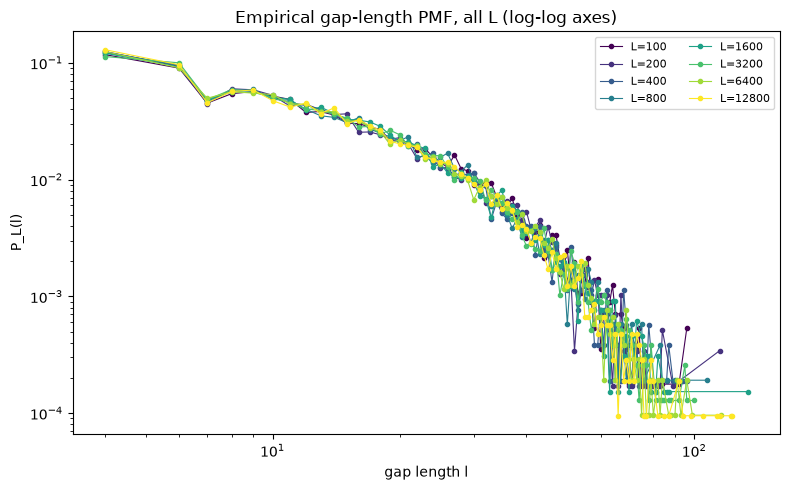

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for L, color in zip(L_VALUES, cmap):
    arr = gaps[L]
    vals, counts = np.unique(arr, return_counts=True)
    p = counts / len(arr)
    ax.plot(vals, p, marker='o', markersize=3, linewidth=0.8, color=color, label=f'L={L}')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('gap length l')
ax.set_ylabel('P_L(l)')
ax.set_title('Empirical gap-length PMF, all L (log-log axes)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Full-range fit comparison (not just the l>=15 tail)

Researcher observation, 2026-09-14: the semilog PMF plot above looks
straight, which is what an exponential distribution predicts (a power
law would look straight on the log-log plot instead, and curved here).
The tail-only fits further below (l>=15) were fit for a different
reason (isolating tail behavior for H2b) and happened to be close
between the two forms there -- repeating the same OLS comparison over
the *entire* observed range (l=4 upward, not just l>=15) checks the
observation directly.

In [5]:
full_rows = []
for L in L_VALUES:
    arr = gaps[L]
    vals, counts = np.unique(arr, return_counts=True)
    p = counts / len(arr)

    exp_fit_full = spstats.linregress(vals, np.log(p))
    pow_fit_full = spstats.linregress(np.log(vals), np.log(p))

    full_rows.append({
        'L': L, 'n_pts': len(vals),
        'R2_exp_full': exp_fit_full.rvalue**2,
        'R2_pow_full': pow_fit_full.rvalue**2,
    })

print(f"{'L':>7} {'n_pts':>6} {'R2_exp(full)':>13} {'R2_pow(full)':>13}")
for r in full_rows:
    print(f"{r['L']:7d} {r['n_pts']:6d} {r['R2_exp_full']:13.4f} {r['R2_pow_full']:13.4f}")

      L  n_pts  R2_exp(full)  R2_pow(full)
    100     76        0.9519        0.8786
    200     78        0.9165        0.8718
    400     81        0.9394        0.8967
    800     75        0.9432        0.8947
   1600     78        0.9103        0.8915
   3200     84        0.9658        0.9036
   6400     87        0.9521        0.8891
  12800     87        0.9151        0.9006


## H2a check: rescaled collapse, <l>_L * P_L(l) vs l / <l>_L

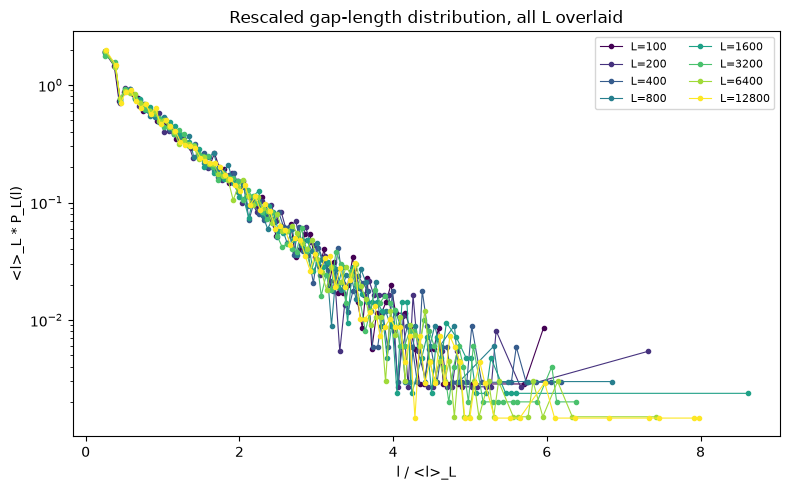

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for L, color in zip(L_VALUES, cmap):
    arr = gaps[L]
    mean_L = arr.mean()
    vals, counts = np.unique(arr, return_counts=True)
    p = counts / len(arr)
    ax.plot(vals / mean_L, mean_L * p, marker='o', markersize=3, linewidth=0.8, color=color, label=f'L={L}')
ax.set_yscale('log')
ax.set_xlabel('l / <l>_L')
ax.set_ylabel('<l>_L * P_L(l)')
ax.set_title('Rescaled gap-length distribution, all L overlaid')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## H2b check: tail fits (exponential vs power-law), l >= 15

Cutoff l=15 is chosen as roughly at/above the pooled mean (~15.4-16.1
across L), to focus the fit on the tail rather than the l=4 spike and
the forbidden-value region below it. Both forms are fit via ordinary
least squares on log(P_L(l)) (vs l for exponential, vs log(l) for
power-law) over the same observed points -- not a claim that either
form is correct, just a comparison of fit quality and whether either
model's parameter drifts with L.

In [7]:
CUTOFF = 15
rows = []
for L in L_VALUES:
    arr = gaps[L]
    vals, counts = np.unique(arr, return_counts=True)
    mask = vals >= CUTOFF
    v, p = vals[mask], counts[mask] / len(arr)

    exp_fit = spstats.linregress(v, np.log(p))
    lam = -1.0 / exp_fit.slope
    pow_fit = spstats.linregress(np.log(v), np.log(p))
    alpha = -pow_fit.slope

    rows.append({
        'L': L, 'n_tail_points': len(v),
        'lambda_exp': lam, 'R2_exp': exp_fit.rvalue**2,
        'alpha_pow': alpha, 'R2_pow': pow_fit.rvalue**2,
    })

print(f"{'L':>7} {'n_pts':>6} {'lambda(exp)':>12} {'R2(exp)':>8} {'alpha(pow)':>11} {'R2(pow)':>8}")
for r in rows:
    print(f"{r['L']:7d} {r['n_tail_points']:6d} {r['lambda_exp']:12.3f} {r['R2_exp']:8.4f} "
          f"{r['alpha_pow']:11.3f} {r['R2_pow']:8.4f}")

      L  n_pts  lambda(exp)  R2(exp)  alpha(pow)  R2(pow)
    100     66       13.264   0.9307       3.226   0.9198
    200     68       13.857   0.8811       3.253   0.8971
    400     71       13.896   0.9153       3.277   0.9310
    800     65       13.781   0.9195       3.196   0.9343
   1600     68       14.590   0.8756       3.264   0.9278
   3200     74       13.525   0.9535       3.388   0.9508
   6400     77       13.308   0.9342       3.546   0.9327
  12800     77       15.003   0.8892       3.465   0.9402


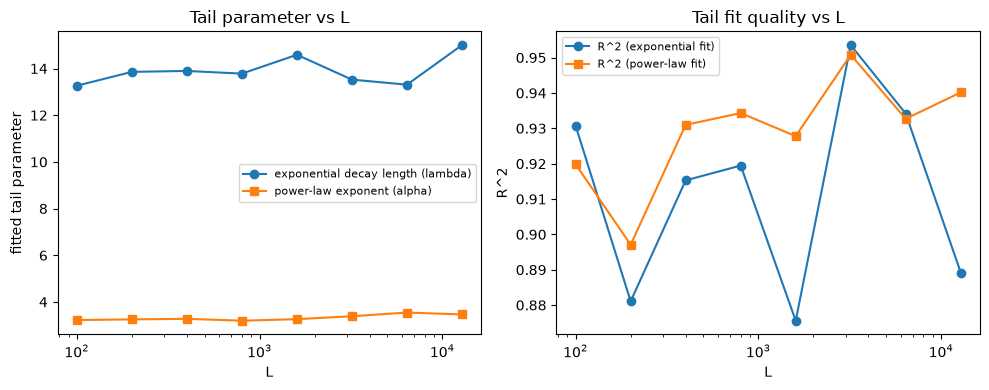

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
Ls = [r['L'] for r in rows]

axes[0].plot(Ls, [r['lambda_exp'] for r in rows], marker='o', label='exponential decay length (lambda)')
axes[0].plot(Ls, [r['alpha_pow'] for r in rows], marker='s', label='power-law exponent (alpha)')
axes[0].set_xscale('log')
axes[0].set_xlabel('L')
axes[0].set_ylabel('fitted tail parameter')
axes[0].legend(fontsize=8)
axes[0].set_title('Tail parameter vs L')

axes[1].plot(Ls, [r['R2_exp'] for r in rows], marker='o', label='R^2 (exponential fit)')
axes[1].plot(Ls, [r['R2_pow'] for r in rows], marker='s', label='R^2 (power-law fit)')
axes[1].set_xscale('log')
axes[1].set_xlabel('L')
axes[1].set_ylabel('R^2')
axes[1].legend(fontsize=8)
axes[1].set_title('Tail fit quality vs L')

fig.tight_layout()
plt.show()

## Not yet done

- No formal model-selection criterion (e.g. AIC) is computed here --
  only R^2 of the two fits, side by side.
- The forbidden-length observation above (l=1,2,3,5 absent) is not
  explained or connected to the move rule here -- flagged for the
  researcher, not investigated further in this notebook.
- Tail-only cutoff l=15 was chosen once, not scanned -- fit
  parameters/R^2 there could be sensitive to that choice; not checked.
  (The separate full-range comparison above is not sensitive to this,
  since it uses no cutoff.)